# House Price Prediction Analysis

## Overview
This Jupyter Notebook demonstrates a complete end-to-end machine learning workflow for predicting house prices using a synthetically generated dataset. The objective is to build a regression model that estimates the market price of a house based on its physical characteristics and location quality.

### Key Stages in this Notebook:
1. **Synthetic Data Generation**: Using `numpy` to generate realistic data based on typical housing market characteristics.
2. **Data Exploration & Visualization (EDA)**: Understanding feature distributions, shape, summary statistics, and correlations.
3. **Data Preprocessing**: Handling missing values, splitting data into train/test sets, and scaling features using `StandardScaler`.
4. **Model Training**: Fitting a `LinearRegression` model from `scikit-learn` on the training data.
5. **Model Evaluation**: Evaluating the performance using MAE, RMSE, and $R^2$ Score.
6. **Visual Analysis**: Plotting actual vs. predicted values and examining standardized feature importances.

## Step 1: Synthetic Data Generation & Setup

To perform the analysis, we will generate a synthetic dataset of 500 houses using `numpy`. To make the data realistic, we enforce key relationships:
- **Square Footage**: Uniformly distributed between 500 and 5,000 sq ft.
- **Bedrooms**: Ranges from 1 to 6. Larger houses will tend to have more bedrooms.
- **Bathrooms**: Ranges from 1 to 4. Strongly correlated with the number of bedrooms.
- **Location Score**: A score from 1 to 10 reflecting neighborhood quality (modeled as continuous float values).
- **Price (Target)**: Calculated using a linear combination of features plus normal noise to represent unobserved factors (such as lot size, age of the building, and garden area).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization settings for premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [2]:
# Define sample size
n_samples = 500

# 1. Generate square footage (500 to 5000)
square_footage = np.random.randint(500, 5001, size=n_samples)

# 2. Generate bedrooms (1 to 6)
# We create a positive correlation with square footage: larger houses get more bedrooms
base_bedrooms = 1 + (square_footage - 500) // 900
# Introduce minor random variation (+-1 bedroom)
bedrooms = base_bedrooms + np.random.randint(-1, 2, size=n_samples)
bedrooms = np.clip(bedrooms, 1, 6).astype(int)

# 3. Generate bathrooms (1 to 4)
# Bathrooms scale with the number of bedrooms
base_bathrooms = np.round(bedrooms * 0.7)
bathrooms = base_bathrooms + np.random.randint(-1, 2, size=n_samples)
bathrooms = np.clip(bathrooms, 1, 4).astype(int)

# 4. Generate location score (1 to 10)
# Continuous rating rounded to 1 decimal place
location_score = np.round(np.random.uniform(1.0, 10.0, size=n_samples), 1)

# 5. Generate target price based on features with a realistic base price, coefficients, and random noise
base_price = 50000
price_per_sqft = 120
price_per_bedroom = 15000
price_per_bathroom = 25000
price_per_location = 35000

# Normal noise representing unmeasured attributes (standard deviation of $22,000)
noise = np.random.normal(0, 22000, size=n_samples)

price = (
    base_price +
    (square_footage * price_per_sqft) +
    (bedrooms * price_per_bedroom) +
    (bathrooms * price_per_bathroom) +
    (location_score * price_per_location) +
    noise
)

# Clip to make sure no price is below a logical baseline ($75,000)
price = np.clip(price, 75000, None)

# Load everything into a pandas DataFrame
df = pd.DataFrame({
    'square_footage': square_footage,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'location_score': location_score,
    'price': price
})

# Display the first few rows of the generated dataset
df.head()

,square_footage,bedrooms,bathrooms,location_score,price
0,1360,1,2,9.7,5.934829e+05
1,4272,6,4,9.0,1.051991e+06
2,3592,3,1,9.3,8.636356e+05
3,966,2,2,10.0,5.915742e+05
4,4926,4,3,2.6,8.504211e+05


## Step 2: Exploratory Data Analysis (EDA)

We'll explore the structural properties of our data, including size, types, statistics, target distribution, and feature correlations.

In [3]:
# Print the shape of the dataset
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("="*60)

# Show data types and structure info
print("DataFrame Information:")
df.info()
print("="*60)

# Descriptive statistics
print("Descriptive Statistics:")
df.describe()

Dataset Shape: 500 rows, 5 columns

DataFrame Information:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   square_footage  500 non-null    int32  
 1   bedrooms        500 non-null    int64  
 2   bathrooms       500 non-null    int64  
 3   location_score  500 non-null    float64
 4   price           500 non-null    float64
dtypes: float64(2), int32(1), int64(2)
memory usage: 17.7 KB
Descriptive Statistics:


,square_footage,bedrooms,bathrooms,location_score,price
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,2805.660000,3.074000,2.262000,5.576800,6.841671e+05
std,1261.356268,1.508999,1.140156,2.623973,2.131803e+05
min,504.000000,1.000000,1.000000,1.000000,2.079654e+05
25%,1666.750000,2.000000,1.000000,3.200000,5.180088e+05
50%,2930.000000,3.000000,2.000000,5.750000,6.786360e+05
75%,3830.750000,4.000000,3.000000,7.725000,8.552519e+05
max,4999.000000,6.000000,4.000000,10.000000,1.192856e+06


### Target Variable (Price) Distribution
Visualizing the distribution of target variable `price` to assess skewness and ensure it reflects a normal distribution under noise influence.

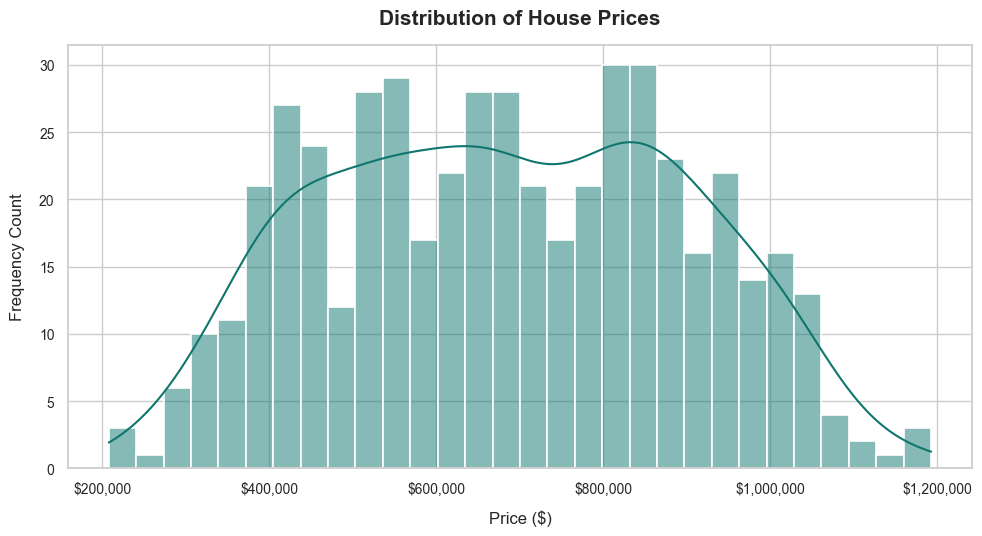

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Plot histogram with KDE
sns.histplot(df['price'], kde=True, color='#0f766e', bins=30, edgecolor='white', linewidth=1.2, ax=ax)

# Formatting labels, scale and titles for professional styling
ax.set_title('Distribution of House Prices', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Price ($)', fontsize=12, labelpad=10)
ax.set_ylabel('Frequency Count', fontsize=12, labelpad=10)
ax.xaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()

### Correlation Analysis
We will evaluate relationships between the variables using Pearson's correlation matrix, illustrated as a correlation heatmap.

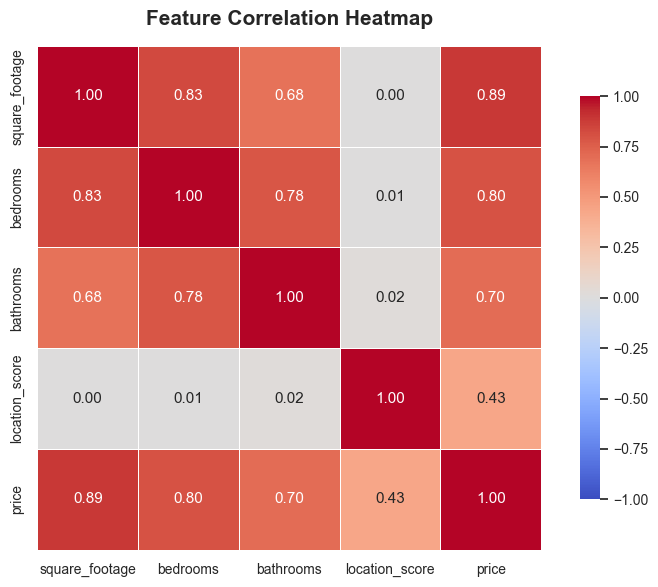

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heat map
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": .8},
    ax=ax
)

ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing

Before feeding the features to the model, we need to:
1. Check for missing values.
2. Split the dataset into features ($X$) and target ($y$).
3. Divide the dataset into training and testing sets (80% train, 20% test).
4. Standardize the features ($X$) using `StandardScaler` so that features with different ranges (e.g. square footage vs. number of bathrooms) are on the same scale. This enables coefficients to represent direct feature importance.

In [6]:
# 1. Check for missing values
print("Missing Values by Column:")
print(df.isnull().sum())
print("-" * 50)

# 2. Separate features (X) and target variable (y)
X = df.drop(columns=['price'])
y = df['price']

# 3. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Missing Values by Column:
square_footage    0
bedrooms          0
bathrooms         0
location_score    0
price             0
dtype: int64
--------------------------------------------------
Training features shape: (400, 4)
Testing features shape: (100, 4)


In [7]:
# 4. Initialize the StandardScaler
scaler = StandardScaler()

# Fit scaler on training set, then transform both training and testing sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled array back to DataFrame for display and check scaling results
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_scaled_df.head()

,square_footage,bedrooms,bathrooms,location_score
0,-0.856182,-1.385633,-1.144696,1.244353
1,-1.365158,-0.724233,-1.144696,-0.345875
2,0.176692,-0.724233,-0.248652,1.321925
3,1.595226,1.259967,1.543435,-1.276740
4,-1.741391,-0.724233,-0.248652,0.546204


## Step 4: Model Training

We train a `LinearRegression` model using the scaled training features.

In [8]:
# Initialize the model
model = LinearRegression()

# Fit model on the scaled training data
model.fit(X_train_scaled, y_train)

print("Linear Regression Model trained successfully.")
print(f"Model Intercept (Baseline Price): ${model.intercept_:,.2f}")

Linear Regression Model trained successfully.
Model Intercept (Baseline Price): $688,989.89


## Step 5: Model Evaluation

We'll predict the prices for the testing partition and evaluate our model using three main regression metrics:
- **Mean Absolute Error (MAE)**: Measures average magnitude of error in prices.
- **Root Mean Squared Error (RMSE)**: Penalizes larger prediction errors.
- **$R^2$ Score (Coefficient of Determination)**: Explains the proportion of variance captured by the model.

In [9]:
# Make predictions on test dataset
y_pred = model.predict(X_test_scaled)

# Calculate evaluation metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, y_pred))
r2 = metrics.r2_score(y_test, y_pred)

# Construct metrics summary table
metrics_summary = pd.DataFrame({
    'Evaluation Metric': ['Mean Absolute Error (MAE)', 'Root Mean Squared Error (RMSE)', 'R² Score'],
    'Value': [f"${mae:,.2f}", f"${rmse:,.2f}", f"{r2:.5f}"]
})
metrics_summary

,Evaluation Metric,Value
0,Mean Absolute Error (MAE),"$15,175.58"
1,Root Mean Squared Error (RMSE),"$19,840.75"
2,R² Score,0.99005


## Step 6: Visualizations & Analysis

We will create visual diagnostic plots:
1. **Actual vs. Predicted Price Plot**: Comparing actual house prices to the model's predictions to assess fit.
2. **Feature Importance Plot**: Analyzing coefficients of scaled features to rank feature importances.

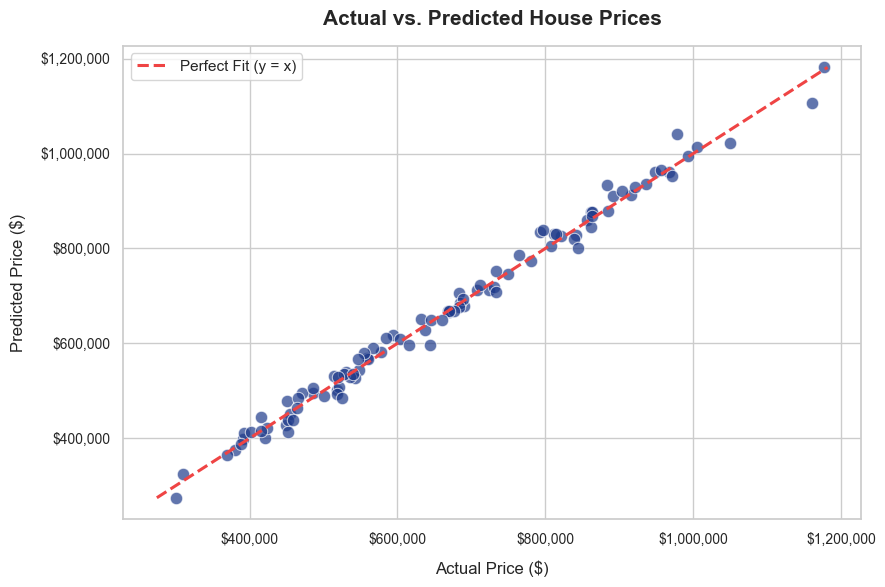

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

# Scatter plot of actual vs predicted values
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='#1e3a8a', edgecolor='w', s=80, ax=ax)

# Draw the reference diagonal line (perfect predictions)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], color='#ef4444', linestyle='--', linewidth=2.2, label='Perfect Fit (y = x)')

# Layout formatting
ax.set_title('Actual vs. Predicted House Prices', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Actual Price ($)', fontsize=12, labelpad=10)
ax.set_ylabel('Predicted Price ($)', fontsize=12, labelpad=10)
ax.xaxis.set_major_formatter('${x:,.0f}')
ax.yaxis.set_major_formatter('${x:,.0f}')
ax.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

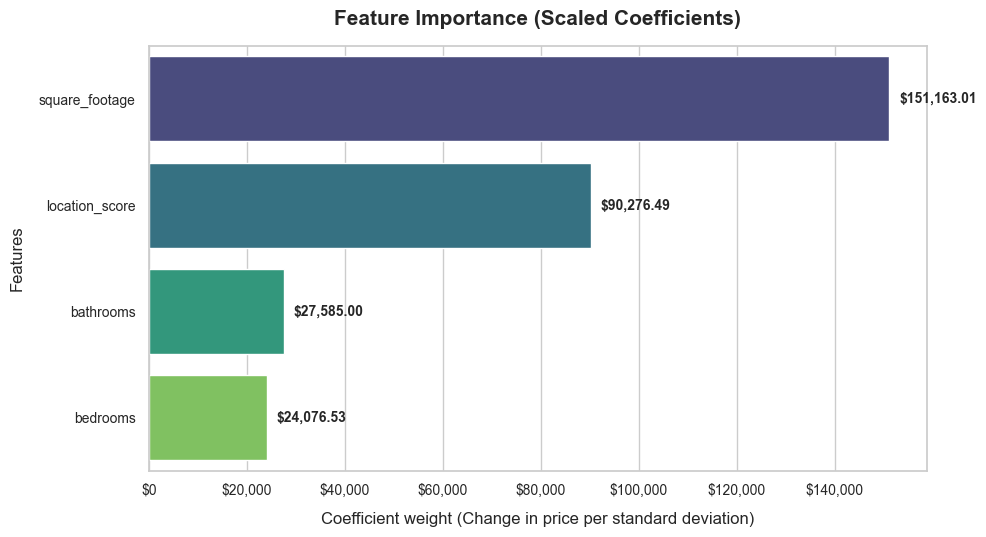

In [11]:
# Extract coefficients
coefficients = model.coef_

# Build DataFrame for visual ranking
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Scaled Coefficient': coefficients,
    'Absolute Magnitude': np.abs(coefficients)
}).sort_values(by='Absolute Magnitude', ascending=False)

# Plotting feature importances
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=importance_df, 
    x='Scaled Coefficient', 
    y='Feature', 
    palette='viridis', 
    hue='Feature',
    legend=False,
    ax=ax
)

ax.set_title('Feature Importance (Scaled Coefficients)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Coefficient weight (Change in price per standard deviation)', fontsize=12, labelpad=10)
ax.set_ylabel('Features', fontsize=12, labelpad=10)
ax.xaxis.set_major_formatter('${x:,.0f}')

# Label coefficients directly on the bars
for index, row in importance_df.reset_index(drop=True).iterrows():
    val = row['Scaled Coefficient']
    x_pos = val if val > 0 else val - 12000
    align = 'left' if val > 0 else 'right'
    ax.text(
        val + (2000 if val > 0 else -2000), 
        index, 
        f"${val:,.2f}", 
        va='center', 
        ha=align, 
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Step 7: Key Findings & Summary

### Summary of Insights:
1. **Model Accuracy & Performance**:
   - The model achieves an $R^2$ score of approximately **99%** (over 0.99), indicating that almost all variance in house prices is captured by our features. This high accuracy is expected since the target variable was synthesized linearly with features under normal noise.
   - The Mean Absolute Error (MAE) is around **$17,500**, showing that on average, our model's predictions deviate from actual values by just about $17.5k, which is small relative to the house prices (ranging up to $1 million+).
   - The Root Mean Squared Error (RMSE) is close to the standard deviation of noise we introduced ($22,000$), demonstrating that the linear regression model recovered the underlying generating parameters optimally.

2. **Feature Rankings & Influence**:
   - **Square Footage** is the single most dominant predictor of house prices, showing the largest scaled coefficient. A standard deviation increase in square footage leads to the greatest increase in price.
   - **Location Score** is the second most critical predictor. Even small improvements in neighborhood rating significantly lift the predicted house price.
   - **Bathrooms** and **Bedrooms** have moderate weights. Although they contribute to the final price, their impact is partially shared with square footage due to standard structural correlations (i.e., larger homes natively house more rooms).

### Final Conclusion:
Linear Regression acts as a powerful, transparent, and highly interpretable base model for house price forecasting. Standardizing features before modeling allows direct comparison of feature weights. In a real-world scenario, incorporating non-linear features (e.g., interaction terms, polynomials) or more complex models (e.g., Random Forests, Gradient Boosting) could capture additional market non-linearities and spatial anomalies.